In [1]:
import pandas as pd

# Upload file manually in Colab first
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv('Telco-Customer-Churn.csv')

# Preview
df.head()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Basic structure
df.info()

# Statistical summary
df.describe()

# Check first rows again
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Replace empty strings with NaN
df['TotalCharges'] = df['TotalCharges'].replace(" ", pd.NA)

# Convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Check missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [4]:
df = df.dropna()

In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


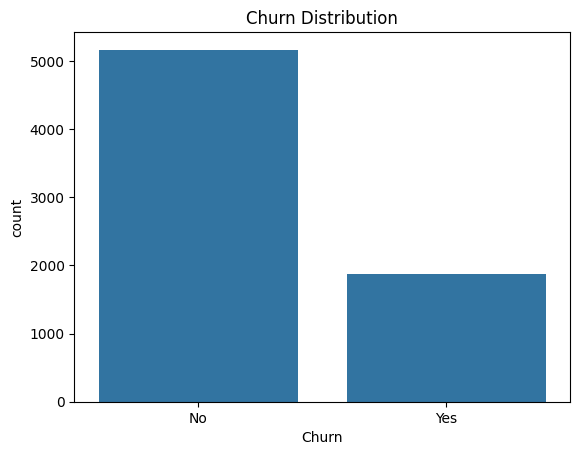

,proportion
Churn,
No,73.421502
Yes,26.578498


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Churn count
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

# Percentage
df['Churn'].value_counts(normalize=True) * 100

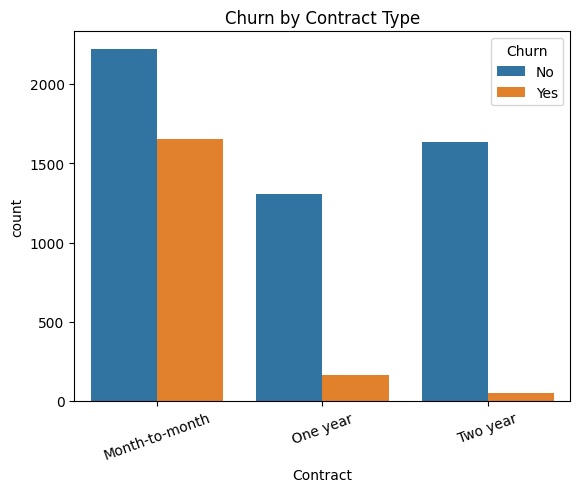

In [7]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.xticks(rotation=20)
plt.show()

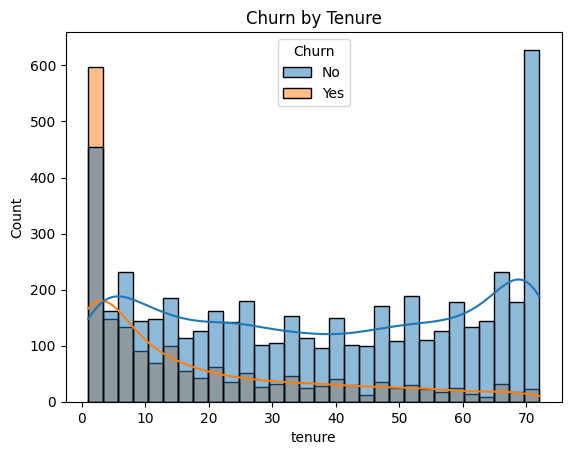

In [8]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Churn by Tenure')
plt.show()

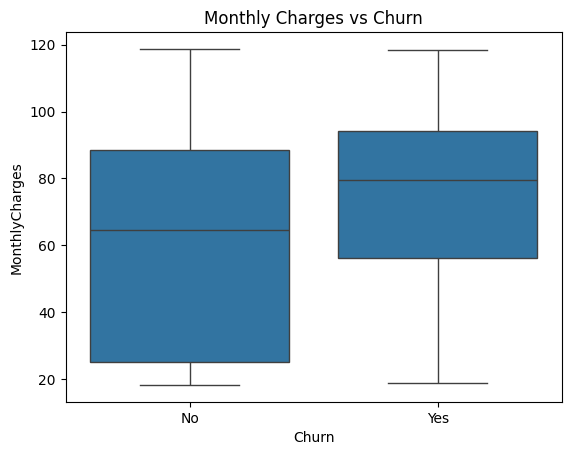

In [9]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

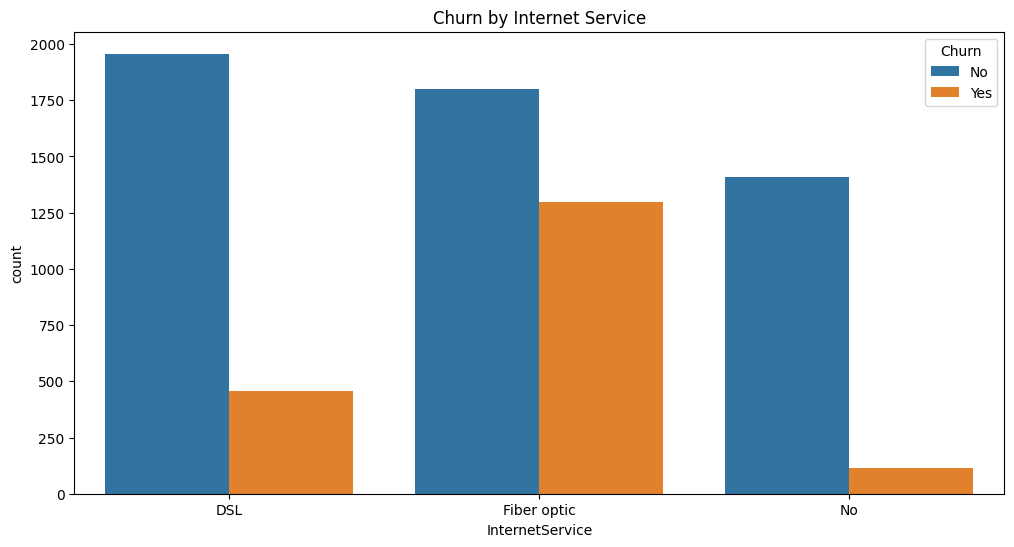

In [10]:
plt.figure(figsize=(12,6))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service')
plt.show()

In [11]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.246862,0.825880
MonthlyCharges,0.246862,1.000000,0.651065
TotalCharges,0.825880,0.651065,1.000000


In [12]:
# Churn rate by contract (percentage)
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [13]:
df = df.drop('customerID', axis=1)

In [14]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [15]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [16]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("First 5 columns:")
print(X_train.columns[:5])

X_train shape: (5625, 30)
X_test shape: (1407, 30)
First 5 columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male'],
      dtype='object')


In [20]:
from sklearn.linear_model import LogisticRegression

# Initialize model
log_model = LogisticRegression(max_iter=1000)

# Train
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [21]:
# Predictions
y_pred = log_model.predict(X_test_scaled)

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Full report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7874911158493249

Confusion Matrix:
[[915 118]
 [181 193]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [23]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

Decision Tree Accuracy: 0.775408670931059


In [24]:
# Get churn probabilities
y_probs = log_model.predict_proba(X_test_scaled)[:, 1]

In [25]:
results = X_test.copy()

results['Actual_Churn'] = y_test.values
results['Churn_Probability'] = y_probs

In [26]:
def risk_segment(prob):
    if prob > 0.7:
        return 'High Risk'
    elif prob > 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

results['Risk_Segment'] = results['Churn_Probability'].apply(risk_segment)

In [27]:
# Count per segment
results['Risk_Segment'].value_counts()

# Average probability per segment
results.groupby('Risk_Segment')['Churn_Probability'].mean()

# Actual churn rate per segment
results.groupby('Risk_Segment')['Actual_Churn'].mean()

,Actual_Churn
Risk_Segment,
High Risk,0.803922
Low Risk,0.132591
Medium Risk,0.507886


In [28]:
# Merge results with original dataset (for readability)
analysis_df = df.loc[X_test.index].copy()
analysis_df['Risk_Segment'] = results['Risk_Segment']

In [29]:
pd.crosstab(analysis_df['Contract'], analysis_df['Risk_Segment'], normalize='columns') * 100

Risk_Segment,High Risk,Low Risk,Medium Risk
Contract,,,
Month-to-month,100.0,37.753036,98.73817
One year,0.0,28.036437,1.26183
Two year,0.0,34.210526,0.00000


In [30]:
pd.crosstab(analysis_df['InternetService'], analysis_df['Risk_Segment'], normalize='columns') * 100

Risk_Segment,High Risk,Low Risk,Medium Risk
InternetService,,,
DSL,2.941176,42.105263,24.290221
Fiber optic,97.058824,28.846154,75.709779
No,0.000000,29.048583,0.000000


In [31]:
analysis_df.groupby('Risk_Segment')['MonthlyCharges'].mean()

,MonthlyCharges
Risk_Segment,
High Risk,84.987255
Low Risk,59.484919
Medium Risk,76.650315


In [32]:
analysis_df.groupby('Risk_Segment')['tenure'].mean()

,tenure
Risk_Segment,
High Risk,6.382353
Low Risk,40.819838
Medium Risk,16.160883
